In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

In [67]:
data_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\merged_df"

# Local Watershed Variables Correlation

In [68]:
df = pd.read_csv(os.path.join(data_directory, "corr_local.csv"))
df = df.rename({"TSS_mean": "TSS", "area_km2": "Surface Area", "mean_loc_chirps":"Precipitation", "mean_discharge":"Discharge",
                 "u_wind_loc": "Eastward Wind Speed","v_wind_loc": "Northward Wind Speed", "anthropogenic_km2": "Anthropic Area","Unnamed: 0": ""}, axis=1).set_index('')   
df = df.rename({"TSS_mean": "TSS", "area_km2": "Surface Area", "mean_loc_chirps":"Precipitation", "mean_discharge":"Discharge",
                 "u_wind_loc": "Eastward Wind Speed","v_wind_loc": "Northward Wind Speed", "anthropogenic_km2": "Anthropic Area"})
df

,TSS,Surface Area,Precipitation,Discharge,Eastward Wind Speed,Northward Wind Speed,Anthropic Area
,,,,,,,
TSS,1.000000,-0.649384,-0.019305,-0.206399,0.120427,0.149660,-0.115633
Surface Area,-0.649384,1.000000,0.030520,0.249901,-0.092296,-0.168965,0.118973
Precipitation,-0.019305,0.030520,1.000000,0.033140,0.251333,-0.377643,0.066447
Discharge,-0.206399,0.249901,0.033140,1.000000,-0.014656,-0.103526,0.081611
Eastward Wind Speed,0.120427,-0.092296,0.251333,-0.014656,1.000000,-0.169516,-0.034337
Northward Wind Speed,0.149660,-0.168965,-0.377643,-0.103526,-0.169516,1.000000,-0.236462
Anthropic Area,-0.115633,0.118973,0.066447,0.081611,-0.034337,-0.236462,1.000000


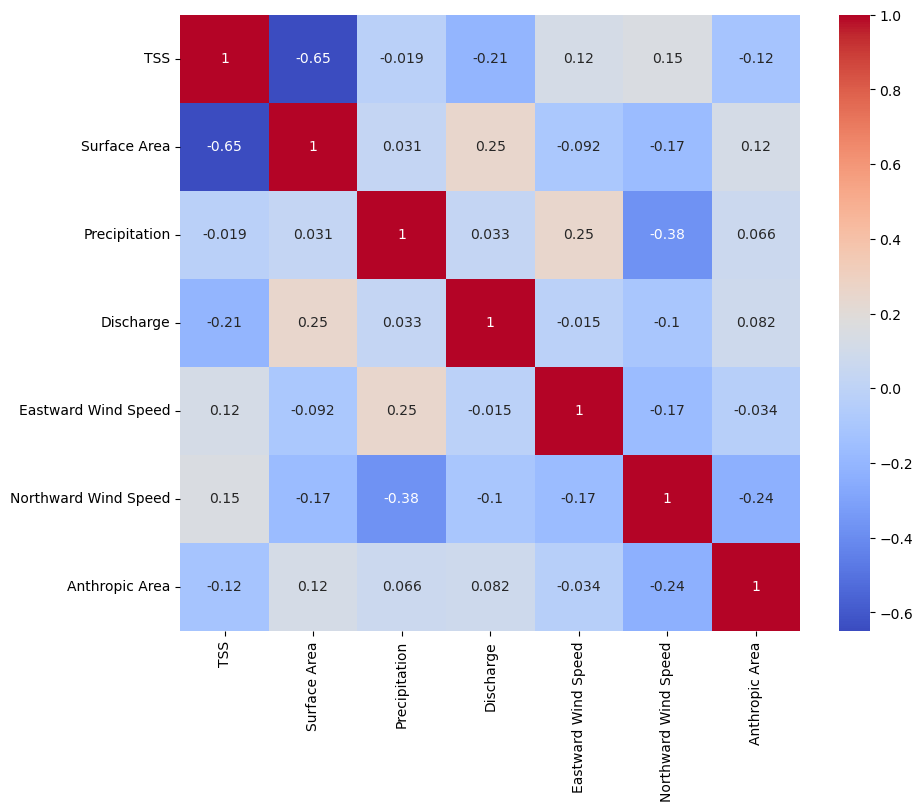

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap='coolwarm',)
plt.savefig(os.path.join(data_directory, 'corr_local.png'),dpi=300)
plt.show()

# Dataframe of correlation results only for TSS

In [75]:
cor_paths = sorted(glob.glob(os.path.join(data_directory, "corr_*_local.csv")))

In [76]:
# Keep only files that DO NOT contain "pattern_to_exclude"
cor_paths = sorted([f for f in cor_paths if ("corr_ci_local" not in f)])
print(cor_paths)

['C:\\Users\\l_v_v\\Documents\\GitHub\\time_series_curuai\\datasets\\Parameters Time series\\merged_df\\corr_p_local.csv', 'C:\\Users\\l_v_v\\Documents\\GitHub\\time_series_curuai\\datasets\\Parameters Time series\\merged_df\\corr_se_local.csv', 'C:\\Users\\l_v_v\\Documents\\GitHub\\time_series_curuai\\datasets\\Parameters Time series\\merged_df\\corr_si_local.csv']


In [78]:
list_dfs = []
for path in cor_paths:
    df_temp = pd.read_csv(path)
    df_temp = df_temp[['Unnamed: 0','TSS_mean']].copy()
    
    name_columns = f'{os.path.basename(path).split("_")[1]}'
    if "si" in name_columns:
        name_columns = "COEF"
    
    df_temp.columns = ["Variables", f'{name_columns.upper()}']
    df_temp = df_temp.loc[df_temp['Variables'] != "TSS_mean"].copy()
    rename_dict = {"area_km2": "Surface Area", "mean_loc_chirps":"Precipitation", 
               "mean_discharge":"Discharge", "u_wind_loc": "Eastward Wind Speed",
               "v_wind_loc": "Northward Wind Speed", "anthropogenic_km2": "Anthropic Area"}
    df_temp['Variables'] = df_temp['Variables'].map(rename_dict)
    list_dfs.append(df_temp.set_index('Variables') )

df_merged = pd.concat(list_dfs, axis=1)
df_merged.to_csv(os.path.join(data_directory, 'corr_local_stats.csv'))
df_merged

,P,SE,COEF
Variables,,,
Surface Area,1.112347e-31,0.062936,-0.65***
Precipitation,7.277177e-01,0.082745,-0.02
Discharge,2.432366e-04,0.080979,-0.21***
Eastward Wind Speed,2.986511e-02,0.082158,0.12*
Northward Wind Speed,6.952870e-03,0.081829,0.15**
Anthropic Area,3.877246e-02,0.082205,-0.12*
